<a href="https://colab.research.google.com/github/encen-ya/PCVK_Genap2026/blob/main/Week5_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Kreszen Vallentino Arjuna Wijono'
NIM = '244107020206'
N = int(NIM[-3:])
PARAM = {
    'bins': 2**((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2**((N % 3) + 1)
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM  :', NIM, 'N =', N)
for k, v in PARAM.items():
    print('%-6s: %s' % (k, v))
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
kunci = NIM + ' ' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
print('SISTEM:', sys.version.split()[0], platform.platform())

NAMA : Kreszen Vallentino Arjuna Wijono
NIM  : 244107020206 N = 206
bins  : 32
clip  : 1.5
tile  : 4
L     : 8
WAKTU : 2026-09-29 20:30:36 WIB
TOKEN : 064bacbbe233d3e6
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39


In [ ]:

import os, math, glob
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Drive tidak dipasang (tidak apa-apa bila memakai upload):', e)

CONTOH = '/content/drive/MyDrive/PCVK/Images'
BASE   = '/content/drive/MyDrive/PCVK/Images/'


if not os.path.exists(CONTOH + '/lena.jpg'):
    CONTOH = '/content'
if not os.path.exists(BASE + '/KTM1b.jpg'):
    BASE = '/content'
print('CONTOH =', CONTOH); print('BASE   =', BASE)

def jud(t):
    return ' - '
def baca(path, gray=False):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE if gray else cv.IMREAD_COLOR)
    assert img is not None, 'Gambar tidak ditemukan: ' + path
    return img


ROI_TEKS  = (290, 150, 850, 410)
ROI_POLOS = (20, 435, 280, 520)
def potong(img, roi):
    x1, y1, x2, y2 = roi
    return img[y1:y2, x1:x2]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CONTOH = /content/drive/MyDrive/PCVK/Images
BASE   = /content/drive/MyDrive/PCVK/Images/


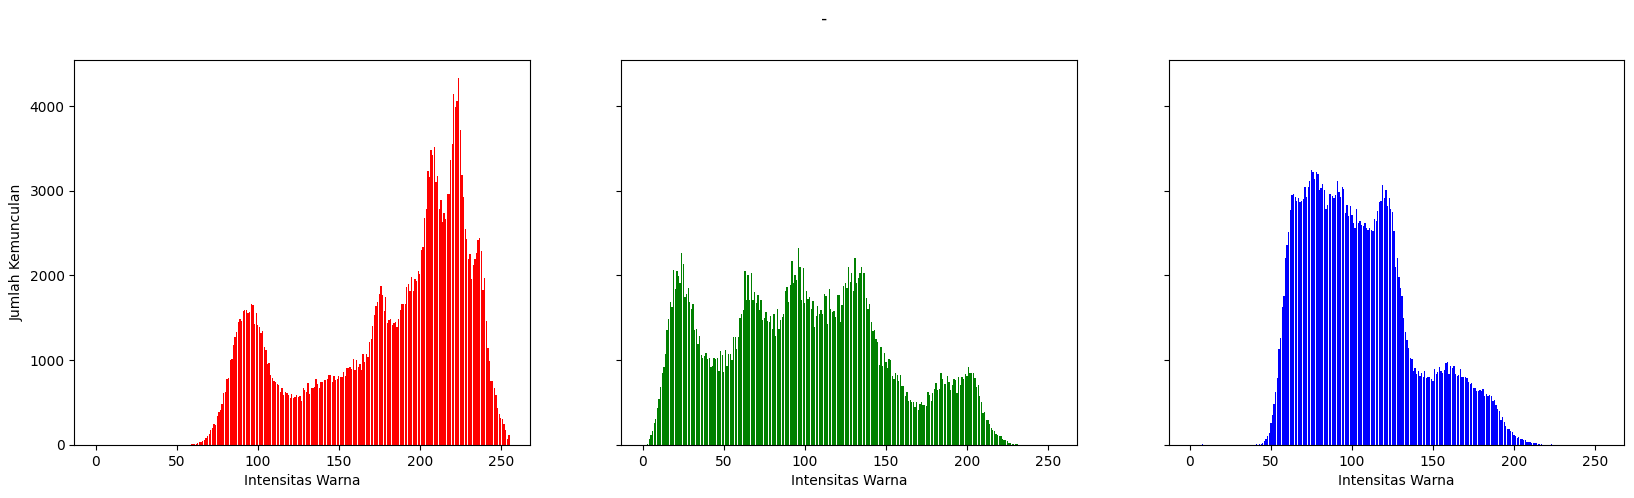

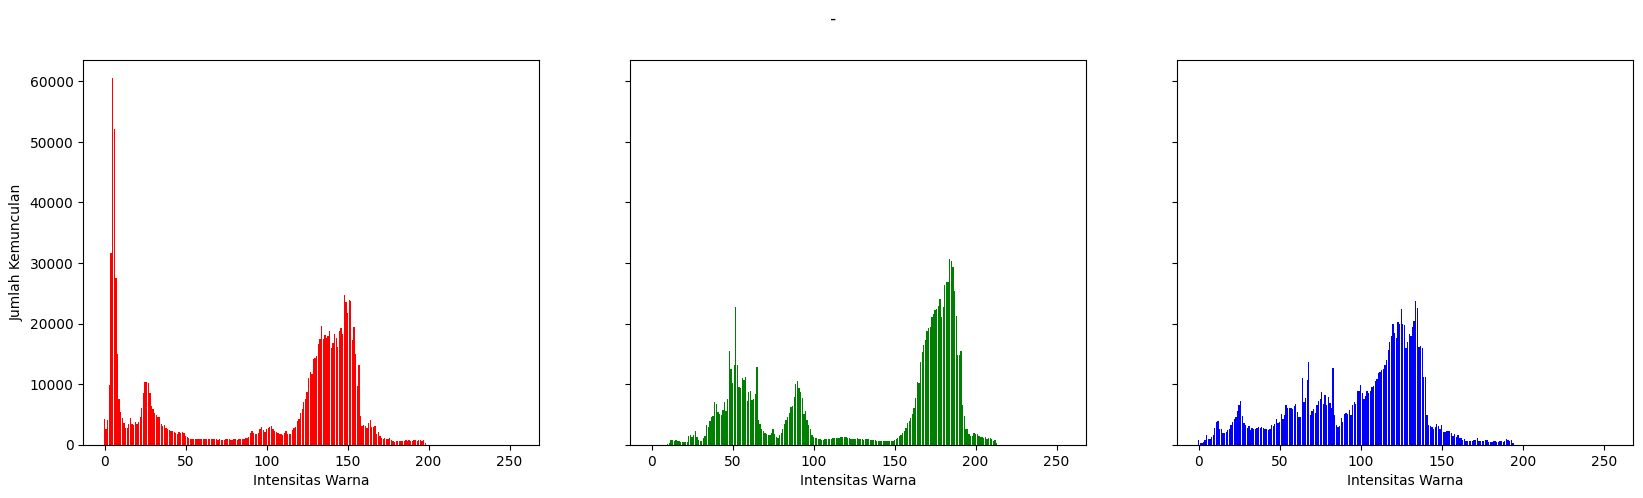

In [ ]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def plot_rgb_manual(path, judul):
    bgr = baca(path)
    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
    fig.suptitle(jud('Histogram RGB - ' + judul))
    for ax, i, warna in zip(axs, range(3), ['red', 'green', 'blue']):
        h = histogram_manual(rgb[:, :, i])
        assert h.sum() == rgb.shape[0] * rgb.shape[1]
        ax.bar(np.arange(256), h, color=warna)
        ax.set_xlabel('Intensitas Warna')
    axs[0].set_ylabel('Jumlah Kemunculan')
    plt.show()

plot_rgb_manual(CONTOH + '/lena.jpg', 'Tahap 1 lena.jpg')
plot_rgb_manual(BASE + '/KTM1b.jpg',  'Tahap 2 KTM1b.jpg')


# Pertanyaan E-1 no. 1:

In [ ]:
def bandingkan_tiga(path, judul):
    g = baca(path, gray=True)
    h_man = histogram_manual(g)
    h_np  = np.histogram(g, bins=256, range=(0, 256))[0]
    h_cv  = cv.calcHist([g], [0], None, [256], [0, 256]).flatten().astype(np.int64)
    d1 = np.abs(h_man - h_np).max(); d2 = np.abs(h_man - h_cv).max(); d3 = np.abs(h_np - h_cv).max()
    print('%-14s | manual-numpy: %d | manual-calcHist: %d | numpy-calcHist: %d' % (judul, d1, d2, d3))
    assert d1 == 0 and d2 == 0 and d3 == 0
bandingkan_tiga(CONTOH + '/lena.jpg', 'lena.jpg')
bandingkan_tiga(BASE + '/KTM1b.jpg',  'KTM1b.jpg')
print(jud('Selisih maksimum = 0 -> ketiga cara menghasilkan histogram yang persis sama'))

lena.jpg       | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
KTM1b.jpg      | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
 - 


# Pertanyaan E-1 no. 2:

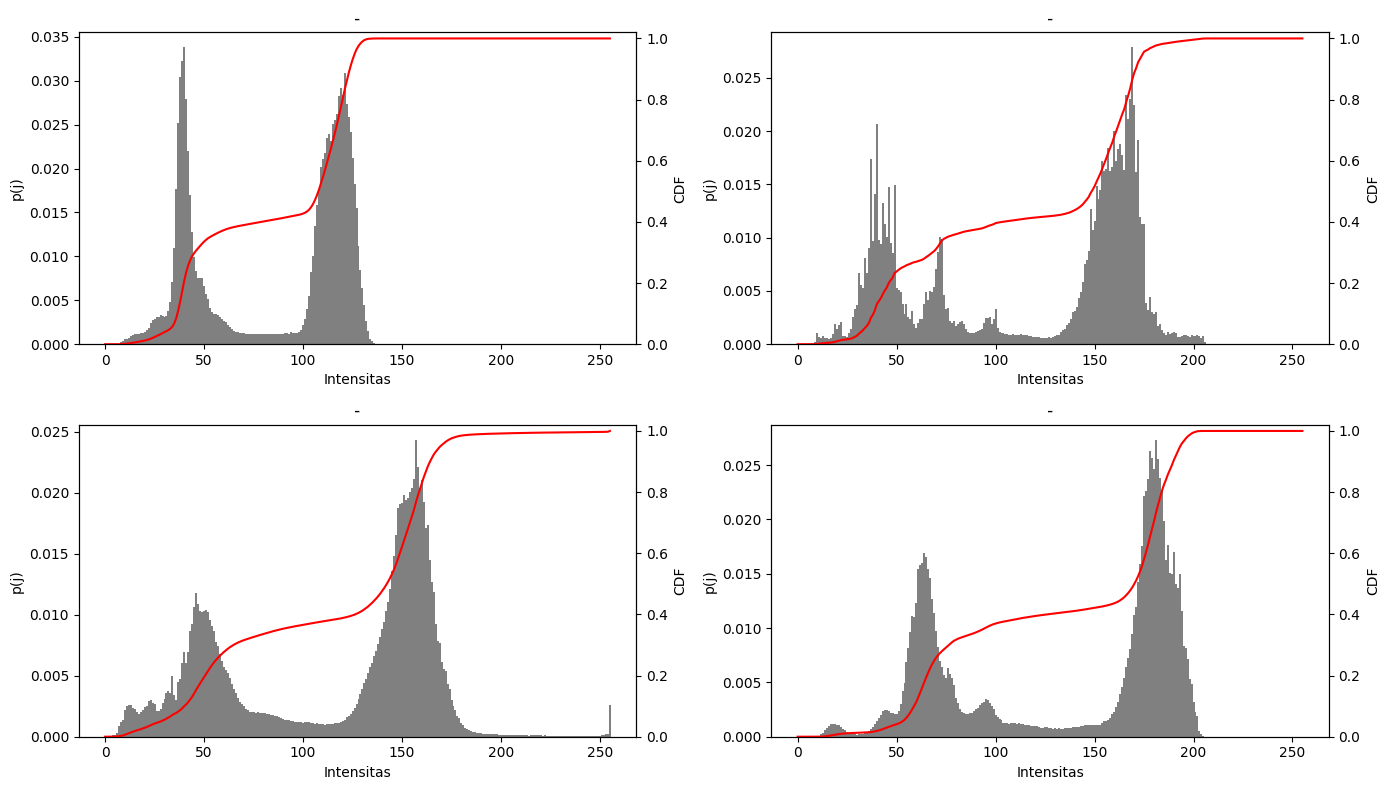

Citra   Kondisi          Rerata   Median   % piksel<=63  % piksel>=192
KTM1a   ruangan gelap      86.2      108          38.0%           0.0%
KTM1b   lampu ruangan     117.2      149          27.7%           1.1%
KTM1c   flash             115.1      143          29.3%           1.0%
KTM1d   matahari          135.1      171          16.2%           8.2%


In [ ]:
nama_file = ['KTM1a', 'KTM1b', 'KTM1c', 'KTM1d']
ket = {'KTM1a': 'ruangan gelap', 'KTM1b': 'lampu ruangan', 'KTM1c': 'flash', 'KTM1d': 'matahari'}
ringkas = {}
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
for ax, n in zip(axs.ravel(), nama_file):
    g = baca(BASE + '/' + n + '.jpg', gray=True)
    p = np.bincount(g.ravel(), minlength=256) / g.size
    cdf = np.cumsum(p)
    ax.bar(np.arange(256), p, color='gray', width=1.0, label='p(j)')
    ax.set_ylabel('p(j)'); ax.set_xlabel('Intensitas')
    ax2 = ax.twinx(); ax2.plot(cdf, color='red', label='CDF'); ax2.set_ylim(0, 1.02); ax2.set_ylabel('CDF')
    ax.set_title(jud(n + ' (' + ket[n] + ')'))
    ringkas[n] = dict(rerata=g.mean(), median=int(np.searchsorted(cdf, 0.5)),
                      gelap=cdf[63], terang=max(0.0, 1 - cdf[191]))
plt.tight_layout(); plt.show()
print('%-7s %-14s %8s %8s %14s %14s' % ('Citra', 'Kondisi', 'Rerata', 'Median', '% piksel<=63', '% piksel>=192'))
for n in nama_file:
    r = ringkas[n]
    print('%-7s %-14s %8.1f %8d %13.1f%% %13.1f%%' % (n, ket[n], r['rerata'], r['median'], r['gelap']*100, r['terang']*100))

# Pertanyaan E-1 no. 3

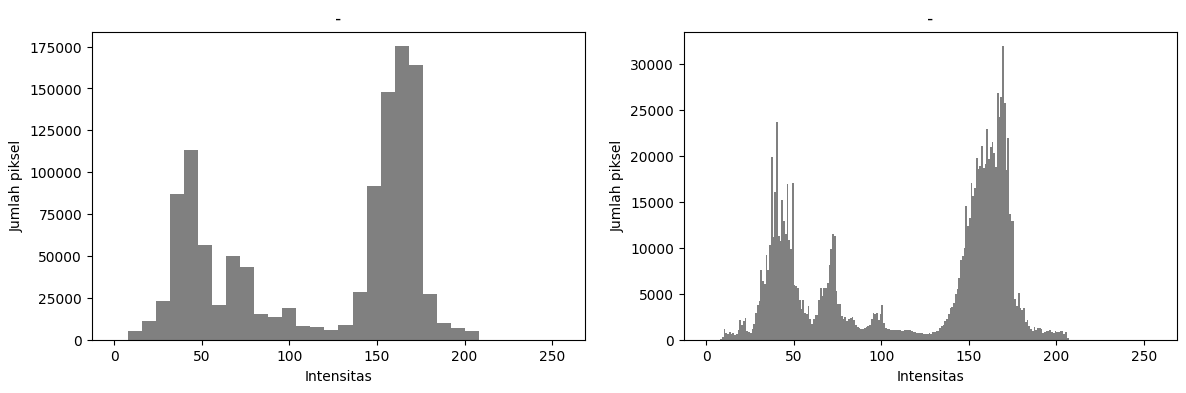

In [ ]:
g = baca(BASE + '/KTM1b.jpg', gray=True)
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
for ax, b in zip(axs, [PARAM['bins'], 256]):
    ax.hist(g.ravel(), bins=b, range=(0, 256), color='gray')
    ax.set_title(jud('KTM1b - %d bin' % b)); ax.set_xlabel('Intensitas'); ax.set_ylabel('Jumlah piksel')
plt.show()

# E-2 Percobaan Histogram Equalization
## E-2 langkah 1: equalization manual (Tahap 1: lena_lc.jpg, Tahap 2: KTM1a.jpg)

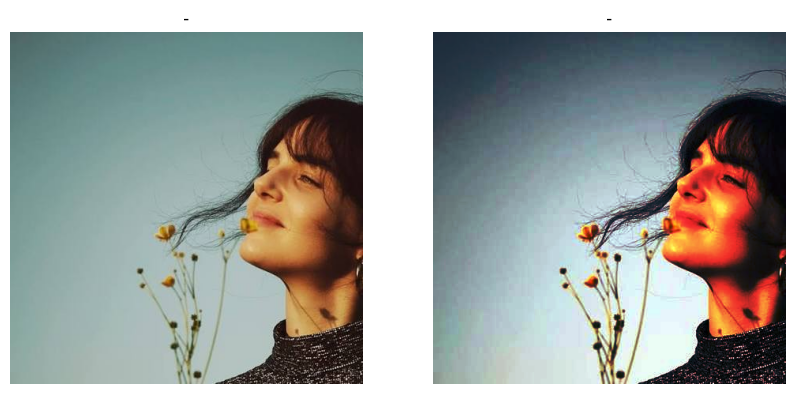

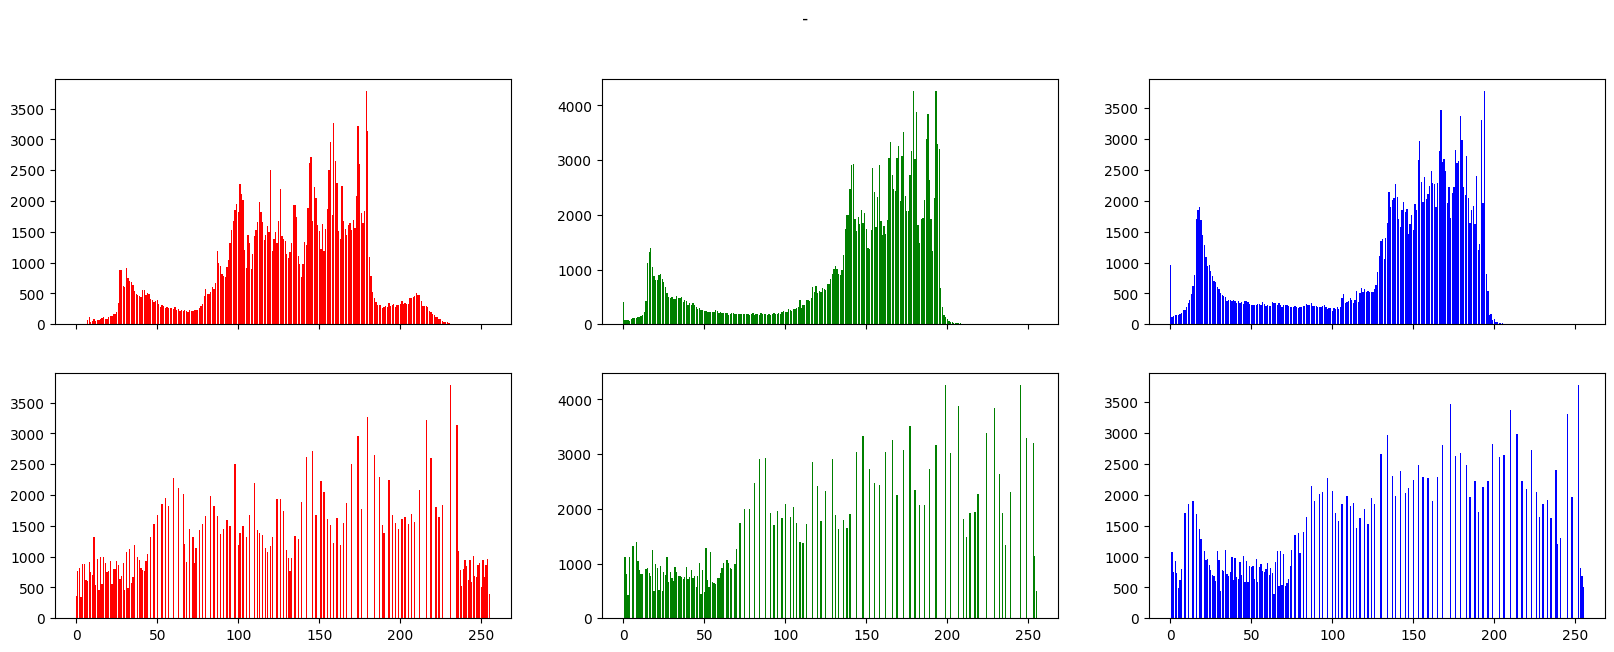

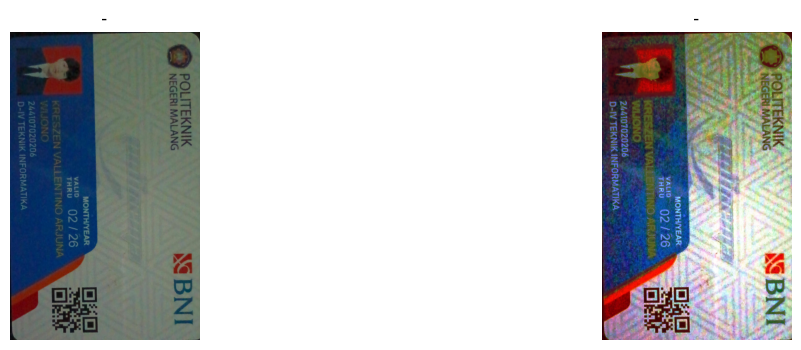

In [ ]:
def he_manual_lut(g):
    """Sesuai modul: K = round(C_i * (2^k - 1) / (w*h)), lalu dipetakan ke semua piksel."""
    h   = histogram_manual(g)
    cdf = np.cumsum(h)
    K   = np.round(cdf * 255 / g.size).astype(np.uint8)
    return K
def he_manual(g):
    return he_manual_lut(g)[g]

def he_manual_color(bgr):
    return cv.merge([he_manual(c) for c in cv.split(bgr)])

# --- Tahap 1: lena_lc (berwarna, tiap kanal) ---
lc = baca(BASE + '/lena_lc.jpg'); lc_he = he_manual_color(lc)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(lc, cv.COLOR_BGR2RGB)); plt.title(jud('lena_lc asli')); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(lc_he, cv.COLOR_BGR2RGB)); plt.title(jud('lena_lc hasil HE manual')); plt.axis('off')
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(20, 7), sharex=True)
fig.suptitle(jud('Histogram RGB lena_lc: atas = sebelum, bawah = sesudah HE'))
for j, warna in enumerate(['blue', 'green', 'red']):
    axs[0, 2-j].bar(np.arange(256), histogram_manual(lc[:, :, j]), color=warna)
    axs[1, 2-j].bar(np.arange(256), histogram_manual(lc_he[:, :, j]), color=warna)
plt.show()

# --- Tahap 2: KTM1a (grayscale dan berwarna) ---
ktm_a = baca(BASE + '/KTM1a.jpg'); ktm_a_he = he_manual_color(ktm_a)
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(ktm_a, cv.COLOR_BGR2RGB)); plt.title(jud('KTM1a asli')); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(ktm_a_he, cv.COLOR_BGR2RGB)); plt.title(jud('KTM1a hasil HE manual')); plt.axis('off')
plt.show()

# E2 - Langkah 2

In [ ]:
def selisih_maks(path, judul):
    g   = baca(path, gray=True)
    man = he_manual(g)
    ocv = cv.equalizeHist(g)
    d = np.abs(man.astype(int) - ocv.astype(int))
    print('%-12s selisih maksimum = %d | piksel berbeda = %.2f%%' % (judul, d.max(), (d > 0).mean() * 100))
    return g

selisih_maks(BASE + '/lena_lc.jpg', 'lena_lc.jpg')
g_a = selisih_maks(BASE + '/KTM1a.jpg', 'KTM1a.jpg')

# Pembuktian penyebab: OpenCV memakai CDF yang dikurangi nilai CDF minimum (cdf_min)
def he_manual_cdfmin(g):
    h = histogram_manual(g); cdf = np.cumsum(h); cmin = cdf[cdf > 0].min()
    lut = np.round((cdf - cmin) / (g.size - cmin) * 255).clip(0, 255).astype(np.uint8)
    return lut[g]
for path in [BASE + '/lena_lc.jpg', BASE + '/KTM1a.jpg']:
    g = baca(path, gray=True)
    print(os.path.basename(path), '-> selisih HE manual (versi cdf_min) vs equalizeHist:',
          np.abs(he_manual_cdfmin(g).astype(int) - cv.equalizeHist(g).astype(int)).max())

lena_lc.jpg  selisih maksimum = 1 | piksel berbeda = 16.42%
KTM1a.jpg    selisih maksimum = 0 | piksel berbeda = 0.00%
lena_lc.jpg -> selisih HE manual (versi cdf_min) vs equalizeHist: 0
KTM1a.jpg -> selisih HE manual (versi cdf_min) vs equalizeHist: 0


Perbedaan hasil yang tidak bernilai nol disebabkan oleh ketidaksamaan antara rumus dasar di modul ($K = \text{round}(C_i \cdot 255 / (w \cdot h))$) dan algoritma bawaan OpenCV. Pada pendekatannya, OpenCV melakukan pengurangan dengan nilai CDF paling kecil (cdf_min) sejak awal proses.

# E2 - Langkah 3

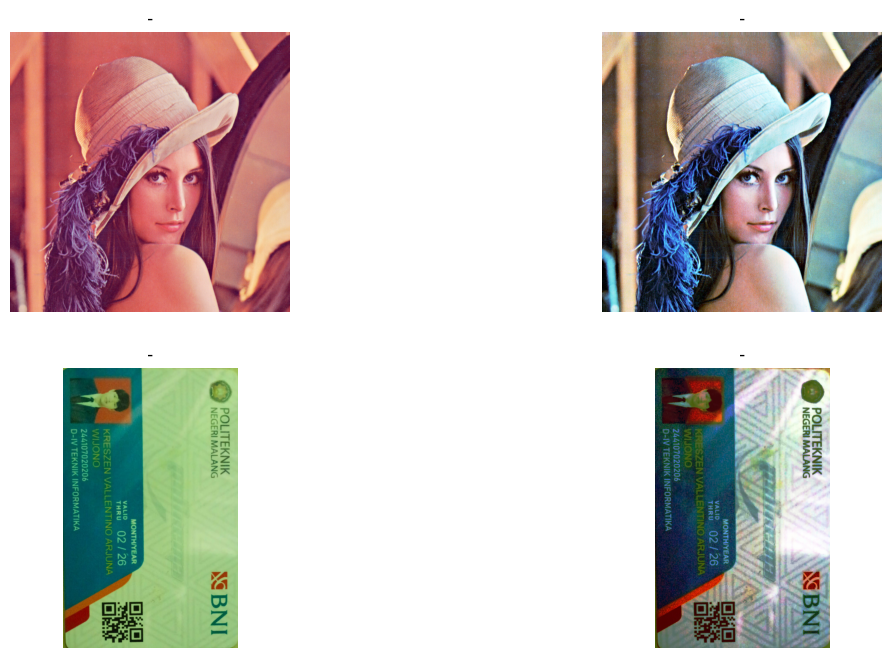

In [ ]:
bgr_lena = baca(BASE + '/lena.jpg')
bgr_ktm  = baca(BASE + '/KTM1d.jpg')

def cara1(bgr):
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    return cv.merge(kanal)

plt.figure(figsize=(14, 8))
for k, (b, t) in enumerate([(bgr_lena, 'lena.jpg'), (bgr_ktm, 'KTM1d.jpg')]):
    plt.subplot(2, 2, 2*k+1); plt.imshow(cv.cvtColor(b, cv.COLOR_BGR2RGB)); plt.title(jud(t + ' asli')); plt.axis('off')
    plt.subplot(2, 2, 2*k+2); plt.imshow(cv.cvtColor(cara1(b), cv.COLOR_BGR2RGB)); plt.title(jud(t + ' - HE per kanal B,G,R')); plt.axis('off')
plt.show()

# E-2 langkah 4

=== Tahap 1: lena.jpg ===


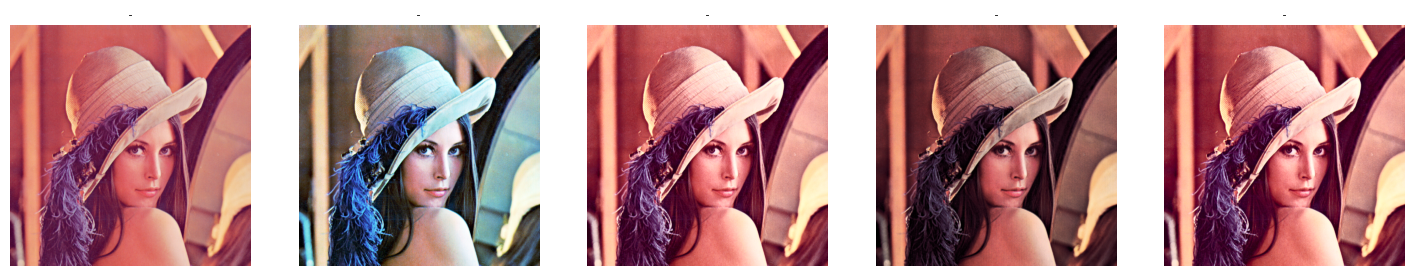

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            124.0
Ekualisasi B, G, R                74.86            128.3
Kanal Y                            2.02            128.0
Kanal V                            0.68             91.2
Kanal L                            2.61            121.6
=== Tahap 2: KTM1d.jpg ===


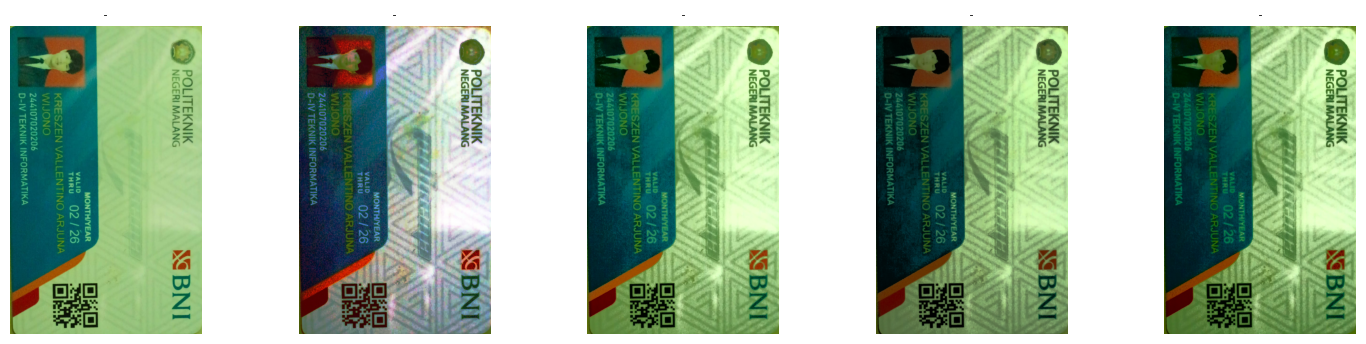

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            135.2
Ekualisasi B, G, R                58.89            125.2
Kanal Y                            1.62            130.4
Kanal V                            0.65            111.4
Kanal L                            2.78            116.3


In [ ]:
def semua_cara(bgr):
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb); y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV); h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB); l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)
    return [bgr, cara1(bgr), he_y, he_v, he_l]

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d  = np.abs(h1 - h2)
    d  = np.minimum(d, 180 - d)          # Hue melingkar 0-179
    return d.mean()

def tampil_dan_tabel(bgr, nama):
    citra = semua_cara(bgr)
    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i); plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(jud(nama + ' - ' + t), fontsize=8); plt.axis('off')
    plt.show()
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    hasil = {}
    for t, c in zip(judul, citra):
        gs = geser_hue(bgr, c) * 2; tr = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        hasil[t] = (gs, tr)
        print('%-22s %16.2f %16.1f' % (t, gs, tr))
    return hasil

print('=== Tahap 1: lena.jpg ==='); tab_lena = tampil_dan_tabel(bgr_lena, 'lena')
print('=== Tahap 2: KTM1d.jpg ==='); tab_ktm  = tampil_dan_tabel(bgr_ktm, 'KTM1d')

In [ ]:

uji = {k: v[0] for k, v in tab_ktm.items() if k != 'Asli'}
terbesar = max(uji, key=uji.get)
print('Pergeseran Hue terbesar: "%s" = %.2f derajat' % (terbesar, uji[terbesar]))


Pergeseran Hue terbesar: "Ekualisasi B, G, R" = 58.89 derajat




1.   Ekualisasi kanal B, G, R. (Untuk nilainya, kamu harus melihat hasil eksekusi programmu sendiri, tapi metode ini pasti yang paling besar pergeseran warnanya karena mengubah proporsi RGB secara terpisah).   
2.   Karena saat citra dikembalikan ke format BGR, nilai piksel harus berupa bilangan bulat antara 0-255. Angka desimal akan dibulatkan, dan nilai yang melebihi batas 255 atau di bawah 0 akan dipotong (clipping), sehingga memicu sedikit perubahan proporsi warna.   

3.   Umumnya kanal Y (YCrCb) atau L (LAB) yang paling bagus. Alasannya karena warna asli (misal warna kulit atau latar KTM) tetap natural dan tidak terlihat pudar atau aneh dibandingkan HSV. (Sebutkan bagian wajah/latar di KTM-mu sebagai buktinya).   
4.   Saat menggunakan CLAHE, pergeseran Hue akan jauh lebih kecil dan rerata kecerahannya lebih natural/merata dibandingkan ekualisasi biasa. Ini karena CLAHE membatasi lonjakan kontras secara lokal sehingga warna tidak rusak/terlalu terang.





Cara (KTM1d)                geser Hue (der)    rerata terang
Asli                                   0.00            135.2
equalizeHist kanal Y                   1.62            130.4
CLAHE kanal Y                          0.11            137.8


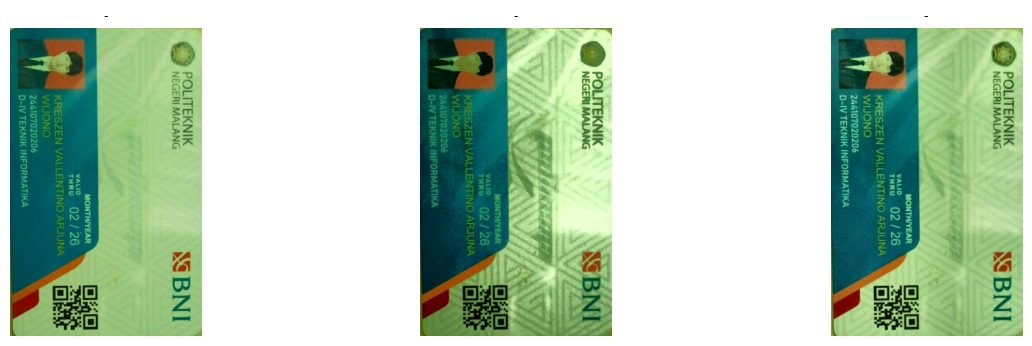

In [ ]:

# No. 4: CLAHE pada kanal terang (Y) memakai parameter dari NIM
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
def he_y_clahe(bgr):
    y, cr, cb = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb))
    return cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

y_biasa = semua_cara(bgr_ktm)[2]
y_clahe = he_y_clahe(bgr_ktm)
print('%-26s %16s %16s' % ('Cara (KTM1d)', 'geser Hue (der)', 'rerata terang'))
for t, c in [('Asli', bgr_ktm), ('equalizeHist kanal Y', y_biasa), ('CLAHE kanal Y', y_clahe)]:
    print('%-26s %16.2f %16.1f' % (t, geser_hue(bgr_ktm, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))
plt.figure(figsize=(15, 4))
for i, (c, t) in enumerate([(bgr_ktm, 'KTM1d asli'), (y_biasa, 'equalizeHist Y'),
                            (y_clahe, 'CLAHE Y clip %s tile %d' % (PARAM['clip'], PARAM['tile']))], 1):
    plt.subplot(1, 3, i); plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB)); plt.title(jud(t), fontsize=9); plt.axis('off')
plt.show()

# Pertanyaan E2 - no 1

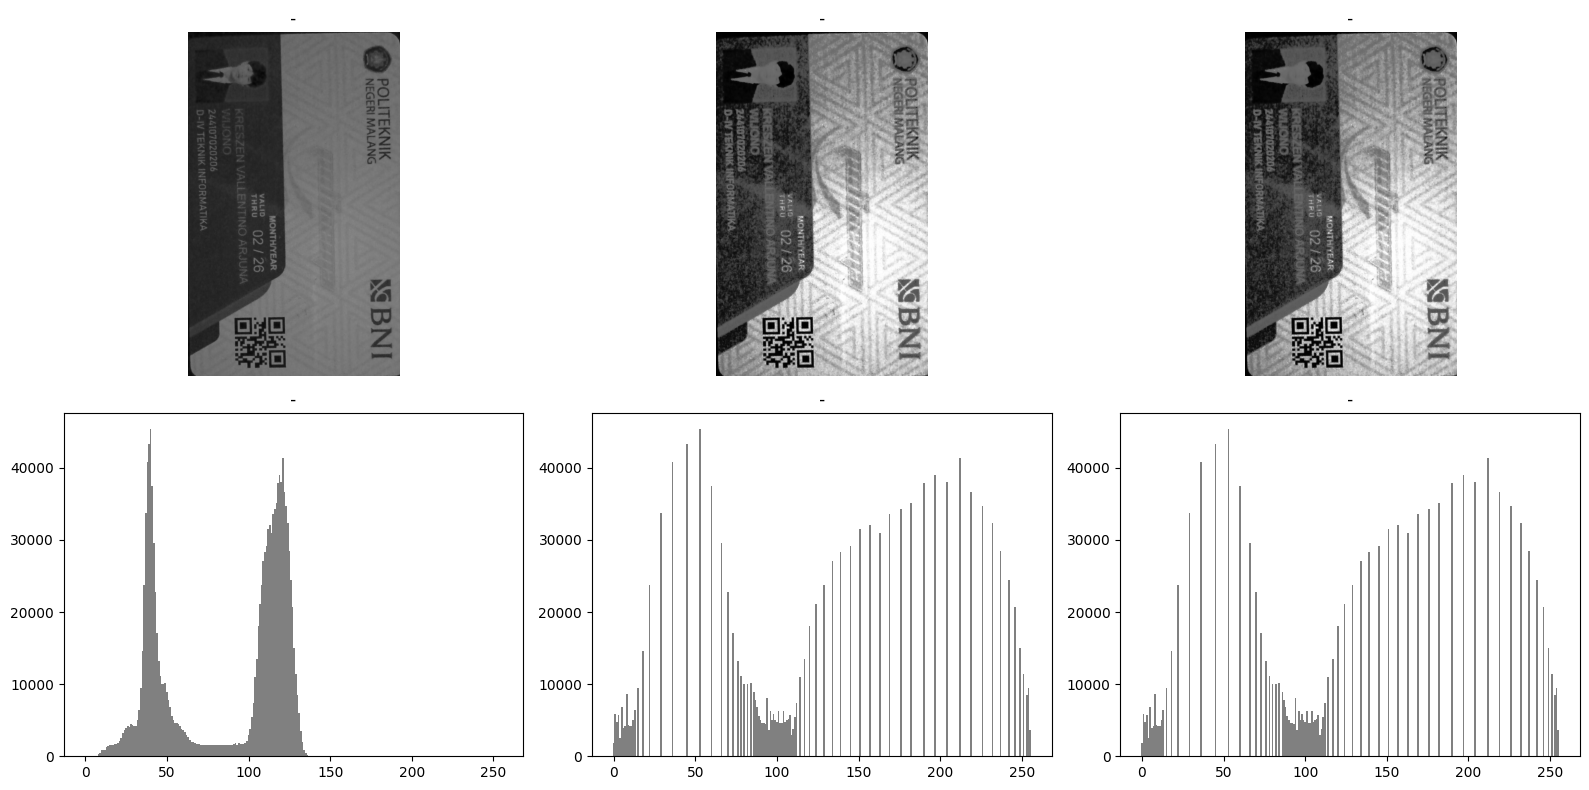

PSNR asli vs HE manual      : 12.62 dB
PSNR asli vs cv.equalizeHist: 12.62 dB
Kontras (std) asli = 37.6 -> sesudah HE = 73.9


In [ ]:
g = baca(BASE + '/KTM1a.jpg', gray=True)
he_m = he_manual(g); he_c = cv.equalizeHist(g)
def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
axs[0,0].imshow(g, cmap='gray', vmin=0, vmax=255); axs[0,0].set_title(jud('KTM1a asli (gray)')); axs[0,0].axis('off')
axs[0,1].imshow(he_m, cmap='gray', vmin=0, vmax=255); axs[0,1].set_title(jud('HE manual')); axs[0,1].axis('off')
axs[0,2].imshow(he_c, cmap='gray', vmin=0, vmax=255); axs[0,2].set_title(jud('cv.equalizeHist')); axs[0,2].axis('off')
for ax, im, t in zip(axs[1], [g, he_m, he_c], ['Histogram asli', 'Histogram HE manual', 'Histogram equalizeHist']):
    ax.bar(np.arange(256), np.bincount(im.ravel(), minlength=256), color='gray', width=1.0); ax.set_title(jud(t))
plt.tight_layout(); plt.show()
print('PSNR asli vs HE manual      : %.2f dB' % psnr(g, he_m))
print('PSNR asli vs cv.equalizeHist: %.2f dB' % psnr(g, he_c))
print('Kontras (std) asli = %.1f -> sesudah HE = %.1f' % (g.std(), he_c.std()))

# jawaban point c
Nilai PSNR turun karena ekualisasi histogram mengubah struktur nilai piksel secara drastis dari citra aslinya demi meratakan kontras. Secara matematis, perubahan besar ini dihitung sebagai "error" yang tinggi (MSE naik), sehingga hasil PSNR-nya menjadi rendah meskipun gambar terlihat lebih jelas.

Pertanyaan E2 - no 2

Citra                    Kontras teks   Ketajaman teks  Noise (polos)
Asli                             29.9             14.5          14.29
Global (equalizeHist)            42.3            180.8          27.63
CLAHE clip 1.5 tile 4            34.9             45.3          26.77


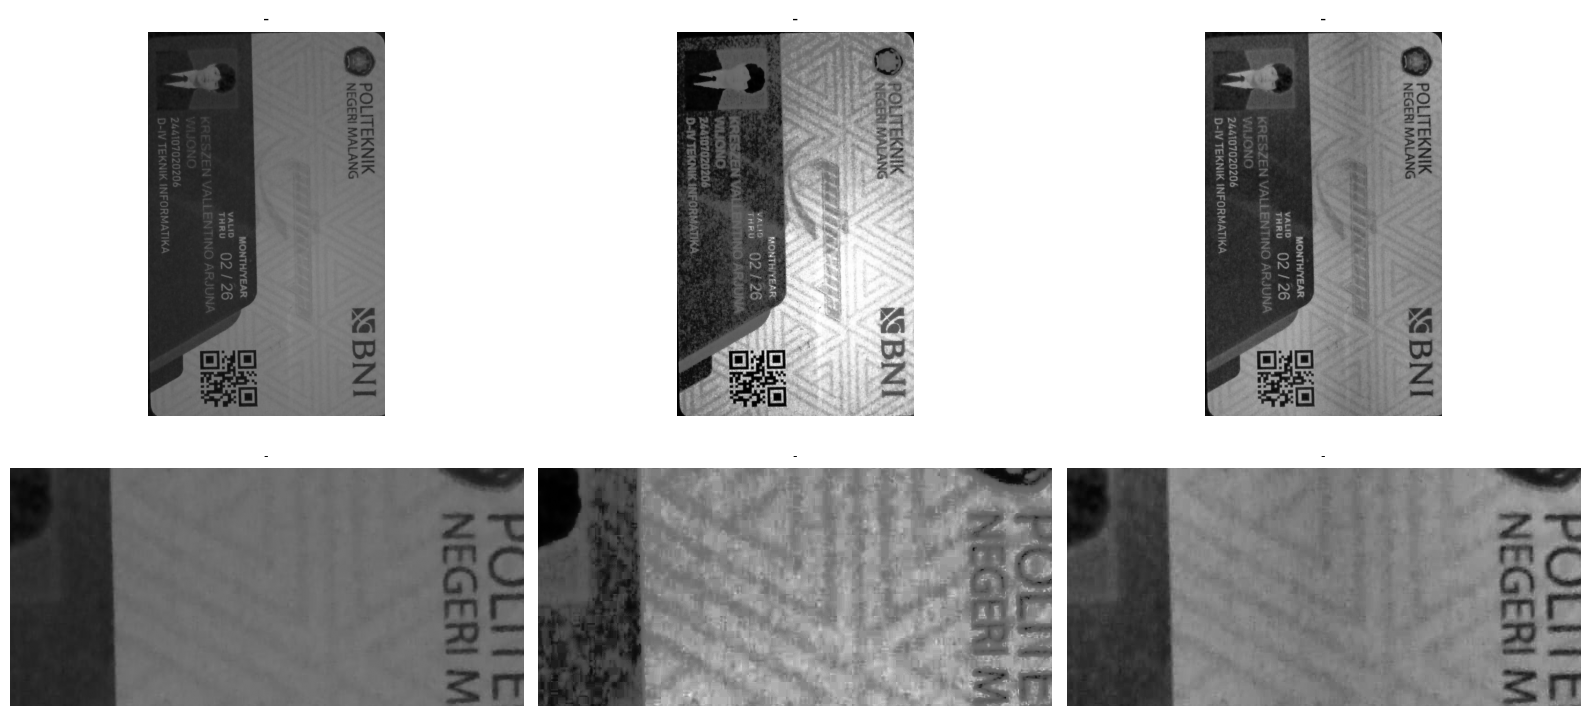

In [ ]:
g = baca(BASE + '/KTM1a.jpg', gray=True)
glob_he = cv.equalizeHist(g)
cl = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile'])).apply(g)

def ukur(im):
    teks = potong(im, ROI_TEKS); polos = potong(im, ROI_POLOS)
    return teks.std(), cv.Laplacian(teks, cv.CV_64F).var(), polos.std()
print('%-22s %14s %16s %14s' % ('Citra', 'Kontras teks', 'Ketajaman teks', 'Noise (polos)'))
for t, im in [('Asli', g), ('Global (equalizeHist)', glob_he), ('CLAHE clip %s tile %d' % (PARAM['clip'], PARAM['tile']), cl)]:
    a, b, c = ukur(im); print('%-22s %14.1f %16.1f %14.2f' % (t, a, b, c))

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for j, (im, t) in enumerate([(g, 'asli'), (glob_he, 'global'), (cl, 'CLAHE')]):
    axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255); axs[0, j].set_title(jud('KTM1a ' + t)); axs[0, j].axis('off')
    axs[1, j].imshow(potong(im, ROI_TEKS), cmap='gray', vmin=0, vmax=255); axs[1, j].set_title(jud('zoom area teks ' + t), fontsize=9); axs[1, j].axis('off')
plt.tight_layout(); plt.show()

clipLimit yang dicoba (selain 1.5): [1.0, 2.0, 2.5]
clipLimit    Kontras teks   Ketajaman teks  Noise (polos)
1.5                  34.9             45.3          26.77
1.0                  34.0             35.4          23.44
2.0                  35.7             56.8          29.39
2.5                  36.6             69.8          31.57


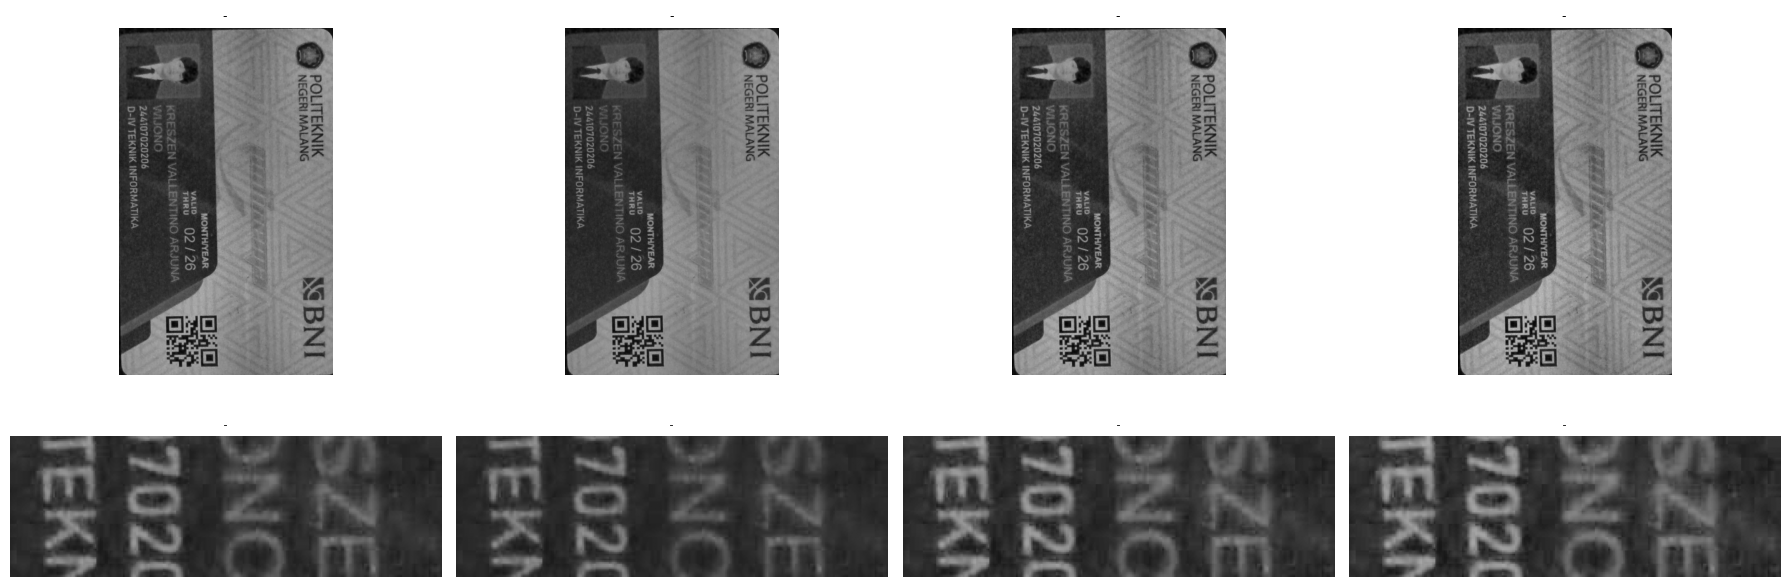

In [ ]:
# b. Tiga nilai clipLimit lain di sekitar nilai
kandidat = sorted([round(PARAM['clip'] + d, 1) for d in (-1.0, -0.5, 0.5, 1.0, 2.0) if PARAM['clip'] + d >= 1.0],
                  key=lambda c: abs(c - PARAM['clip']))[:3]
kandidat = sorted(kandidat)
print('clipLimit yang dicoba (selain %.1f):' % PARAM['clip'], kandidat)
print('%-10s %14s %16s %14s' % ('clipLimit', 'Kontras teks', 'Ketajaman teks', 'Noise (polos)'))
fig, axs = plt.subplots(2, len(kandidat) + 1, figsize=(4.5 * (len(kandidat) + 1), 7))
for j, c in enumerate([PARAM['clip']] + kandidat):
    im = cv.createCLAHE(clipLimit=c, tileGridSize=(PARAM['tile'], PARAM['tile'])).apply(g)
    a, b, n = ukur(im); print('%-10.1f %14.1f %16.1f %14.2f' % (c, a, b, n))
    axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255); axs[0, j].set_title(jud('clip %.1f' % c), fontsize=9); axs[0, j].axis('off')
    axs[1, j].imshow(potong(im, ROI_POLOS), cmap='gray', vmin=0, vmax=255); axs[1, j].set_title(jud('area polos (noise) clip %.1f' % c), fontsize=8); axs[1, j].axis('off')
plt.tight_layout(); plt.show()

# E-3 TUGAS PRAKTIKUM DITHERING

In [ ]:
def floyd_steinberg_float(gray, L=2, langkah=None):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    n = 0
    for y in range(H):
        for x in range(W):
            if langkah is not None and n >= langkah:
                return img
            lama = img[y, x]
            baru = np.round(lama / step) * step          # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                img[y,   x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:      img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y + 1 < H:  img[y+1, x+1] += error * 1 / 16
            n += 1
    return img

def floyd_steinberg(gray, L=2):
    return np.clip(floyd_steinberg_float(gray, L), 0, 255).astype(np.uint8)


kecil = np.array([[200, 120,  90],
                  [ 60, 180,  30],
                  [240, 100, 150]], dtype=np.uint8)
# --- Hitung manual ---
lama = 200.0; baru = 255.0 * round(lama / 255.0); err = lama - baru       # 200 -> 255, error = -55
manual = kecil.astype(np.float32).copy(); manual[0, 0] = baru
manual[0, 1] += err * 7 / 16
manual[1, 0] += err * 5 / 16
manual[1, 1] += err * 1 / 16
# (tetangga kiri-bawah tidak ada karena x = 0)
print('error =', err); print('Hasil manual:\n', manual)
prog = floyd_steinberg_float(kecil, L=2, langkah=1)
print('Hasil program (1 langkah):\n', prog)
assert np.allclose(manual, prog), 'Hitungan manual berbeda dengan program!'
print(jud('Verifikasi BERHASIL: hitungan manual = hasil program'))

error = -55.0
Hasil manual:
 [[255.      95.9375  90.    ]
 [ 42.8125 176.5625  30.    ]
 [240.     100.     150.    ]]
Hasil program (1 langkah):
 [[255.      95.9375  90.    ]
 [ 42.8125 176.5625  30.    ]
 [240.     100.     150.    ]]
 - 


# E-3 no. 1 (Tahap 1: lena.jpg L=2, Tahap 2: KTM1b.jpg)

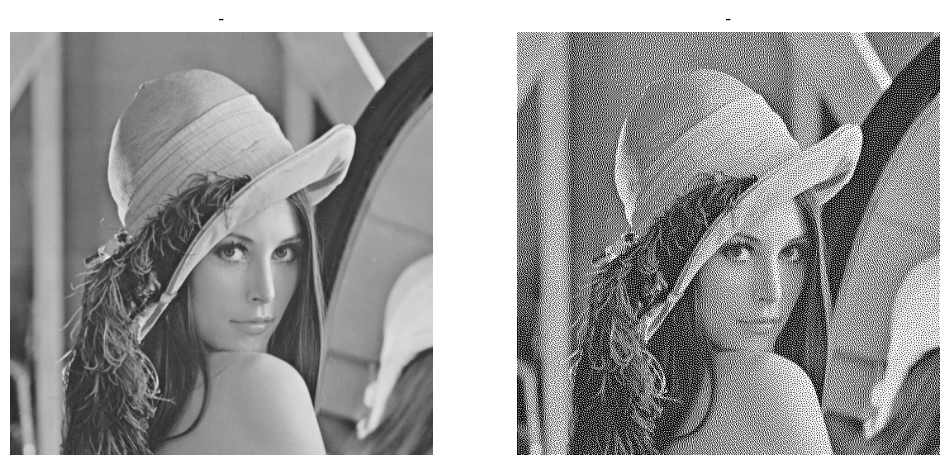

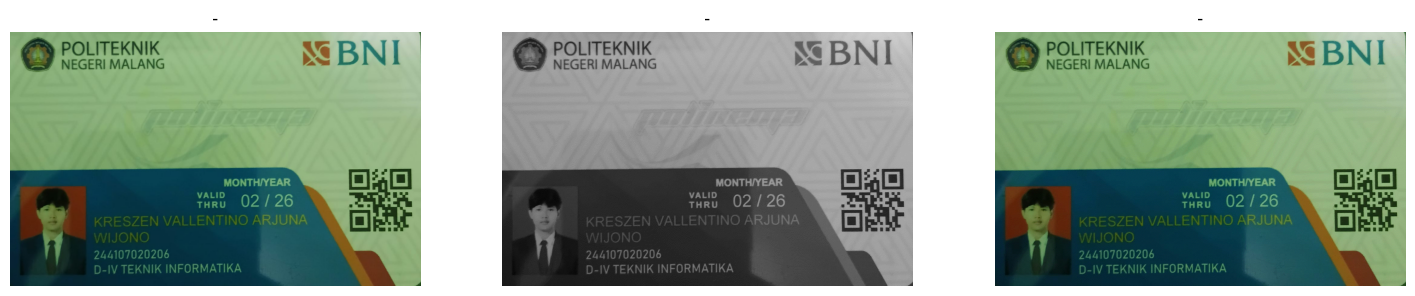

In [ ]:
# Tahap 1: lena.jpg (grayscale, L = 2) untuk mencocokkan gambar contoh modul
lena_g = baca(CONTOH + '/lena.jpg', gray=True)
lena_d = floyd_steinberg(lena_g, L=2)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(lena_g, cmap='gray', vmin=0, vmax=255); plt.title(jud('lena.jpg asli')); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(lena_d, cmap='gray', vmin=0, vmax=255); plt.title(jud('Floyd-Steinberg, L = 2')); plt.axis('off')
plt.show()

# Tahap 2: KTM1b.jpg dengan L dari NIM (grayscale dan berwarna per kanal B, G, R)
ktm_b  = baca(BASE + '/KTM1b.jpg')
ktm_bg = cv.cvtColor(ktm_b, cv.COLOR_BGR2GRAY)
d_gray  = floyd_steinberg(ktm_bg, L=PARAM['L'])
d_color = cv.merge([floyd_steinberg(c, L=PARAM['L']) for c in cv.split(ktm_b)])
plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1); plt.imshow(cv.cvtColor(ktm_b, cv.COLOR_BGR2RGB)); plt.title(jud('KTM1b asli')); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(d_gray, cmap='gray', vmin=0, vmax=255); plt.title(jud('Dithering gray, L = %d' % PARAM['L'])); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(cv.cvtColor(d_color, cv.COLOR_BGR2RGB)); plt.title(jud('Dithering warna B,G,R, L = %d' % PARAM['L'])); plt.axis('off')
plt.show()

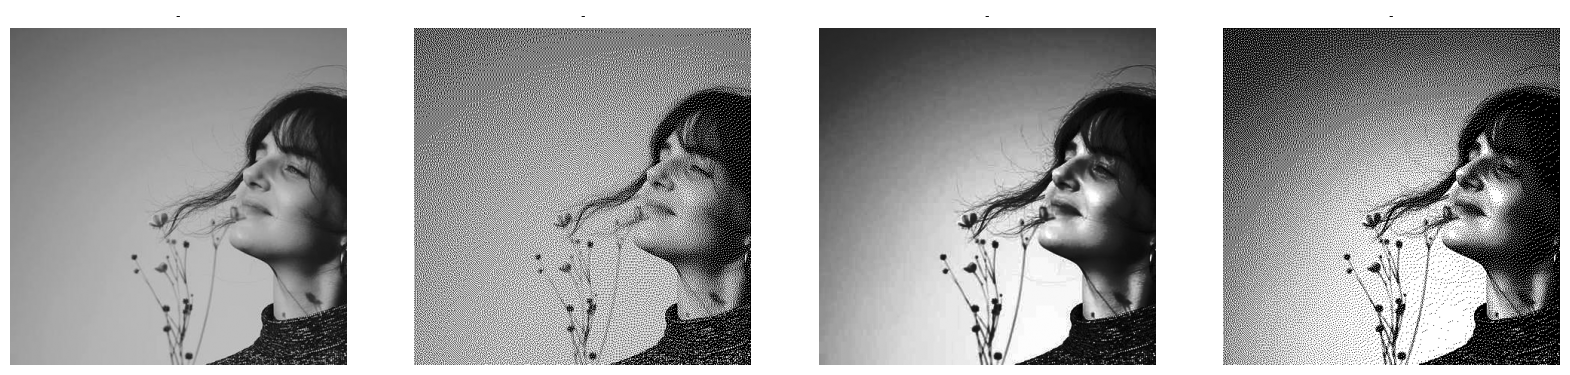

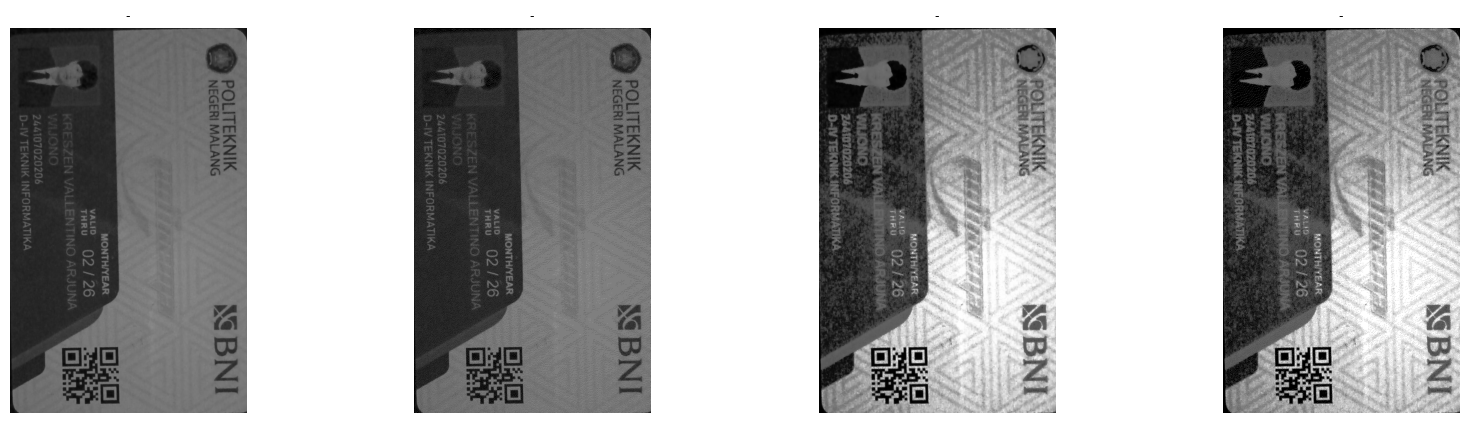

Kontras teks (setelah blur)  langsung: 29.4 | ekualisasi lalu dithering: 41.1


In [ ]:
def urutan_dithering(path, nama, L=2):
    g = baca(path, gray=True)
    langsung = floyd_steinberg(g, L)
    eq       = cv.equalizeHist(g)
    eq_dith  = floyd_steinberg(eq, L)
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    for ax, im, t in zip(axs, [g, langsung, eq, eq_dith],
                         [nama + ' asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']):
        ax.imshow(im, cmap='gray', vmin=0, vmax=255); ax.set_title(jud(t), fontsize=9); ax.axis('off')
    plt.show()
    return g, langsung, eq_dith

urutan_dithering(BASE + '/lena_lc.jpg', 'lena_lc')                    # Tahap 1
g, langsung, eq_dith = urutan_dithering(BASE + '/KTM1a.jpg', 'KTM1a')    # Tahap 2 (L = 2)


def kontras_persepsi(im):
    return cv.GaussianBlur(potong(im, ROI_TEKS).astype(np.float32), (0, 0), 2).std()
print('Kontras teks (setelah blur)  langsung: %.1f | ekualisasi lalu dithering: %.1f' % (kontras_persepsi(langsung), kontras_persepsi(eq_dith)))